<a href="https://colab.research.google.com/github/SATYAPRAKASH1419/Movie_genre_nn/blob/main/Movie_Genre_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introduction to Libraries

This section outlines the purpose of each Python library used in this notebook:

*   **kagglehub**: Downloads datasets directly from Kaggle.
*   **pandas**: Used for loading and manipulating data, similar to spreadsheet software.
*   **numpy**: Provides support for numerical operations, especially with arrays and matrices.
*   **matplotlib & seaborn**: Libraries for creating static, animated, and interactive visualizations in Python.
*   **scikit-learn**: Offers various machine learning algorithms and preprocessing tools, used here for Logistic Regression.
*   **tensorflow**: An open-source machine learning platform, utilized here for building Neural Networks.

In [4]:
# Install required libraries
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn tensorflow -q

### Dataset Download and Verification

This section explains how the dataset is downloaded and verified:

*   `kagglehub.dataset_download()`: This function pulls the specified dataset directly from Kaggle's servers into your Colab session, requiring no Kaggle account credentials.
*   `os.listdir(path)`: After downloading, this command lists the files within the downloaded directory to confirm that the dataset files are present and accessible.

In [5]:
import kagglehub
import pandas as pd

# Download Netflix dataset
path = kagglehub.dataset_download("shivamb/netflix-shows")

import os
#to see what files got downloaded
for f in os.listdir(path):
  print(f)

Using Colab cache for faster access to the 'netflix-shows' dataset.
netflix_titles.csv


### Initial Data Overview

This section provides a quick look at the dataset's basic characteristics:

*   `df.shape`: Shows the number of rows (entries) and columns (features) in the dataset.
*   `df.columns`: Lists all the column names, indicating the type of information available for each entry.
*   `df.head(3)`: Displays the first three rows of the DataFrame, offering a glimpse into the data structure and content.

In [6]:
#load the CSV file
df = pd.read_csv(os.path.join(path, "netflix_titles.csv"))

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)


Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 3 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


### Data Inspection and Key Features

This section highlights crucial aspects of the dataset identified through initial inspection:

*   **Missing Values**: The `isnull().sum()` method reveals the count of missing values in each column, which are important to address before model training.
*   **`listed_in` (Target Column)**: This column represents the genre of the content (e.g., "Documentaries", "Crime TV Shows"), and will serve as our target variable for prediction.
*   **`type` (Content Category)**: This column distinguishes between "Movie" and "TV Show" entries, offering insights into the content distribution.

In [7]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nGenre samples (listed_in column):")
print(df['listed_in'].value_counts().head(10))

print("\nType distribution (Movies vs TV Shows):")
print(df['type'].value_counts())

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Genre samples (listed_in column):
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

Type distribution (Movies vs TV Shows):
type
Movie      6131
TV Show    2676

### Data Cleaning and Preparation

This section focuses on cleaning and preparing the data for model training:

*   **Feature Selection**: Only relevant columns (`title`, `description`, `listed_in`) are retained.
*   **Handle Missing Values**: Rows with missing data in the selected columns are removed.
*   **Genre Simplification**: The `listed_in` column is processed to extract only the primary genre for each entry.
*   **Top Genres Selection**: To simplify the prediction task, the dataset is filtered to include only the top 10 most frequent genres.

In [8]:
# We only need description (input) and listed_in (genre - our target)
df_clean = df[['title','description','listed_in']].dropna()

# Simplify genre - extract FIRST genre only (e.g. "Dramas, International Movies" → "Dramas")
df_clean = df_clean.copy()
df_clean['genre'] = df_clean['listed_in'].apply(lambda x:x.split(',')[0].strip())

# Keep only top 10 genres (so our model isn't overwhelmed)
top_genres = df_clean['genre'].value_counts().head(10).index
df_clean = df_clean[df_clean['genre'].isin(top_genres)]

print("Dataset size after cleaning:", df_clean.shape)
print("\nTop 10 genres we'll predict:")
print(df_clean['genre'].value_counts())

Dataset size after cleaning: (7273, 4)

Top 10 genres we'll predict:
genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


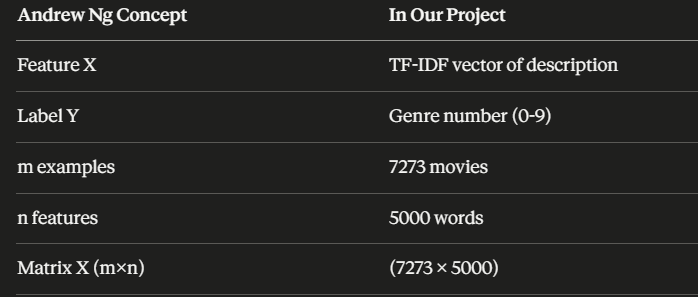

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# STEP A: Convert description text → numbers using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df_clean['description']).toarray()

# STEP B: Convert genre labels → numbers
encoder = LabelEncoder()
y = encoder.fit_transform(df_clean['genre'])

# STEP C: Split into train & test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nGenre → Number mapping:")
for i, genre in enumerate(encoder.classes_):
    print(f"  {i} → {genre}")

X_train shape: (5818, 5000)
X_test shape: (1455, 5000)

Genre → Number mapping:
  0 → Action & Adventure
  1 → Children & Family Movies
  2 → Comedies
  3 → Crime TV Shows
  4 → Documentaries
  5 → Dramas
  6 → Horror Movies
  7 → International TV Shows
  8 → Kids' TV
  9 → Stand-Up Comedy


### Building and Evaluating Logistic Regression Model

This section constructs and assesses a Logistic Regression model for genre classification:

*   **Model Initialization**: A `LogisticRegression` model is instantiated with increased `max_iter` to ensure convergence.
*   **Training**: The model is trained using the `X_train` (TF-IDF features) and `y_train` (encoded genres).
*   **Prediction**: Predictions are made on the `X_test` dataset.
*   **Evaluation**: The model's performance is evaluated using `accuracy_score` and a `classification_report`, providing detailed metrics like precision, recall, and F1-score for each genre.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Build and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_lr, target_names=encoder.classes_))

Logistic Regression Accuracy: 0.4941580756013746

Detailed Report:
                          precision    recall  f1-score   support

      Action & Adventure       0.48      0.49      0.49       157
Children & Family Movies       0.57      0.36      0.44       120
                Comedies       0.40      0.53      0.46       227
          Crime TV Shows       0.55      0.11      0.19        96
           Documentaries       0.78      0.64      0.70       174
                  Dramas       0.40      0.72      0.52       321
           Horror Movies       0.91      0.16      0.28        61
  International TV Shows       0.44      0.22      0.29       153
                Kids' TV       0.73      0.41      0.53        73
         Stand-Up Comedy       0.91      0.71      0.80        73

                accuracy                           0.49      1455
               macro avg       0.62      0.44      0.47      1455
            weighted avg       0.55      0.49      0.48      1455



### Building the Neural Network Model

This section defines the architecture of the Neural Network used for genre classification:

*   **Input Layer**: Consists of 5000 neurons, corresponding to each feature generated by the TF-IDF vectorizer.
*   **Hidden Layer 1**: Contains 128 neurons and uses a ReLU (Rectified Linear Unit) activation function.
*   **Hidden Layer 2**: Contains 64 neurons and also uses a ReLU activation function.
*   **Output Layer**: Has 10 neurons, one for each of the target genres, and uses a Softmax activation function to output probabilities for each genre.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Convert y labels to one-hot encoding
# e.g. genre 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Build Neural Network
model = Sequential([
    Dense(128, activation='relu', input_shape=(5000,)),  # Hidden Layer 1
    Dense(64, activation='relu'),                         # Hidden Layer 2
    Dense(10, activation='softmax')                       # Output Layer
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,034 (2.48 MB)

 Trainable params: 649,034 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

### Training and Evaluating the Neural Network Model

This section focuses on training the Neural Network and then evaluating its performance. It assesses how well the model learns from the training data and generalizes to unseen data.

In [12]:
# Train the Neural Network
history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.2628 - loss: 2.0229 - val_accuracy: 0.4488 - val_loss: 1.6887
Epoch 2/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6329 - loss: 1.1536 - val_accuracy: 0.5065 - val_loss: 1.3863
Epoch 3/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8530 - loss: 0.5277 - val_accuracy: 0.5024 - val_loss: 1.5297
Epoch 4/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9490 - loss: 0.2244 - val_accuracy: 0.4962 - val_loss: 1.7699
Epoch 5/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9904 - loss: 0.0866 - val_accuracy: 0.4818 - val_loss: 2.0245
Epoch 6/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9995 - loss: 0.0349 - val_accuracy: 0.4928 - val_loss: 2.2043
Epoch 7/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9998 - loss: 0.0178 - val_accuracy: 0.4845 - val_loss: 2.3495
Epoch 8/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 0.0110 - val_acc

What Happened?

Epoch 2:  train=63%  val=50%  ← model learning nicely

Epoch 6:  train=99%  val=49%  ← gap starts growing

Epoch 20: train=100% val=47%  ← severe overfit

**Training accuracy = 100% but Test accuracy = 47%**

----------------------------------------
Model memorised the training data instead of learning patterns!


Andrew Ng's Diagnosis

      High Training Accuracy  

      Low Test Accuracy       
              ↓
            OVERFIT!

Exactly like this from his lectures:
Underfit  → high bias   (model too simple)

Just right → balanced   (what we want)

Overfit   → high variance (model too complex) ← we are here

###  The Fix — Regularization!

Andrew Ng's solution → add Dropout (a regularization technique). We'll rebuild the model with fixes:

In [14]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Rebuild model WITH regularization
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(5000,)),
    Dropout(0.4),   # randomly turn off 40% neurons each step
    Dense(64, activation='relu'),
    Dropout(0.3),   # randomly turn off 30% neurons each step
    Dense(10, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping - stops training when val_accuracy stops improving
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,          # stop if no improvement for 3 epochs
    restore_best_weights=True
)

# Train
history2 = model2.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2267 - loss: 2.1153 - val_accuracy: 0.3347 - val_loss: 1.9242
Epoch 2/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4840 - loss: 1.5543 - val_accuracy: 0.4962 - val_loss: 1.4655
Epoch 3/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6757 - loss: 1.0092 - val_accuracy: 0.5100 - val_loss: 1.3990
Epoch 4/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8010 - loss: 0.6578 - val_accuracy: 0.5024 - val_loss: 1.5136
Epoch 5/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8706 - loss: 0.4382 - val_accuracy: 0.4928 - val_loss: 1.6846
Epoch 6/50
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9165 - loss: 0.3001 - val_accuracy: 0.4935 - val_loss: 1.8230


### Data Refinement and TF-IDF Vectorization for Cleaner Model

This section implements further refinements to the dataset and the TF-IDF vectorization process to improve model performance:

*   **Filter for Movies Only**: The dataset is filtered to include only 'Movie' entries, removing 'TV Shows' to reduce complexity and potential noise.
*   **Select Distinct Genres**: The dataset is further filtered to include only five highly distinct genres, simplifying the classification task.
*   **Retrain TF-IDF Vectorizer**: The `TfidfVectorizer` is re-initialized with a larger `max_features` (10000) and `ngram_range=(1,2)` to capture more nuanced word patterns and pairs, providing a richer feature set for the model.
*   **Prepare Data for Training**: The `description` text is transformed into numerical features using the updated TF-IDF vectorizer (`X2`), and the genre labels are encoded (`y2`) and one-hot encoded (`y2_cat`) for the neural network. The data is then split into new training and testing sets (`X2_train`, `X2_test`, `y2_train`, `y2_test`).

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# FIX 1: Keep only Movies (remove TV Shows - they confuse the model)
df_movies = df_clean[df['type'] == 'Movie'].copy()

# FIX 2: Keep only top 5 VERY distinct genres
top5 = ['Stand-Up Comedy', 'Documentaries', 'Horror Movies',
        'Children & Family Movies', 'Action & Adventure']
df_movies = df_movies[df_movies['genre'].isin(top5)]

print("Dataset size:", df_movies.shape)
print("\nGenre distribution:")
print(df_movies['genre'].value_counts())

# FIX 3: Retrain TF-IDF with more features
vectorizer2 = TfidfVectorizer(max_features=10000, stop_words='english',
                               ngram_range=(1,2))  # capture word pairs too!
X2 = vectorizer2.fit_transform(df_movies['description']).toarray()

encoder2 = LabelEncoder()
y2 = encoder2.fit_transform(df_movies['genre'])

y2_cat = to_categorical(y2, num_classes=5)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2_cat, test_size=0.2, random_state=42
)

print("\nX_train shape:", X2_train.shape)
print("Genres:", encoder2.classes_)

/tmp/ipykernel_8287/3316021936.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_movies = df_clean[df['type'] == 'Movie'].copy()


Dataset size: (2902, 4)

Genre distribution:
genre
Action & Adventure          859
Documentaries               829
Children & Family Movies    605
Stand-Up Comedy             334
Horror Movies               275
Name: count, dtype: int64

X_train shape: (2321, 10000)
Genres: ['Action & Adventure' 'Children & Family Movies' 'Documentaries'
 'Horror Movies' 'Stand-Up Comedy']


### Building and Training the Refined Neural Network Model

This section constructs and trains the improved neural network model (`model3`) based on the refined dataset:

*   **Model Architecture**: The model is designed with `Dense` layers, `BatchNormalization` for stable learning, and `Dropout` layers to prevent overfitting.
*   **Compilation**: The model is compiled with the `adam` optimizer, `categorical_crossentropy` loss, and `accuracy` metric.
*   **EarlyStopping**: An `EarlyStopping` callback is used to monitor `val_accuracy` and stop training if there is no improvement for a specified number of epochs, restoring the best weights to prevent overfitting and optimize training time.
*   **Training**: The model is trained using the `X2_train` and `y2_train` data, with `validation_data` set to `(X2_test, y2_test)` to monitor performance on unseen data during training.

In [17]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Build cleaner model for 5 genres
model3 = Sequential([
    Dense(256, activation='relu', input_shape=(10000,)),
    BatchNormalization(),   # stabilizes learning
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')  # 5 genres now!
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor='val_accuracy',
    patience=50,
    restore_best_weights=True
)

history3 = model3.fit(
    X2_train, y2_train,
    epochs=50,
    batch_size=32,
    validation_data=(X2_test, y2_test),
    callbacks=[early_stop2],
    verbose=1
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.3158 - loss: 1.8654 - val_accuracy: 0.2702 - val_loss: 1.5465
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5821 - loss: 1.0937 - val_accuracy: 0.5473 - val_loss: 1.4636
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7725 - loss: 0.6384 - val_accuracy: 0.5645 - val_loss: 1.3479
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8639 - loss: 0.3836 - val_accuracy: 0.6093 - val_loss: 1.1595
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9362 - loss: 0.2088 - val_accuracy: 0.6489 - val_loss: 0.9919
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9565 - loss: 0.1396 - val_accuracy: 0.7143 - val_loss: 0.8286
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9694 - loss: 0.1071 - val_accuracy: 0.7418 - val_loss: 0.7294
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9750 - loss: 0.0811 - val_accuracy: 0.7659 - v

### Visualizing Model Performance: Accuracy and Loss Over Epochs

This section generates plots to visualize the training and validation accuracy and loss over epochs for `model3`. These visualizations are crucial for understanding the model's learning process:

*   **Accuracy Plots**: Show how well the model is performing on both the training data and the unseen validation data over time. A significant gap where training accuracy is high but validation accuracy is low indicates **overfitting**.
*   **Loss Plots**: Illustrate the error rate of the model during training and validation. Similar to accuracy, a widening gap between training loss (decreasing) and validation loss (increasing) is a strong indicator of **overfitting**.
*   **Optimal Point**: The plots help identify the ideal epoch at which `EarlyStopping` would have intervened. This is typically the point where validation loss is at its minimum or validation accuracy is at its maximum before it starts to degrade, preventing the model from overfitting to the training data.

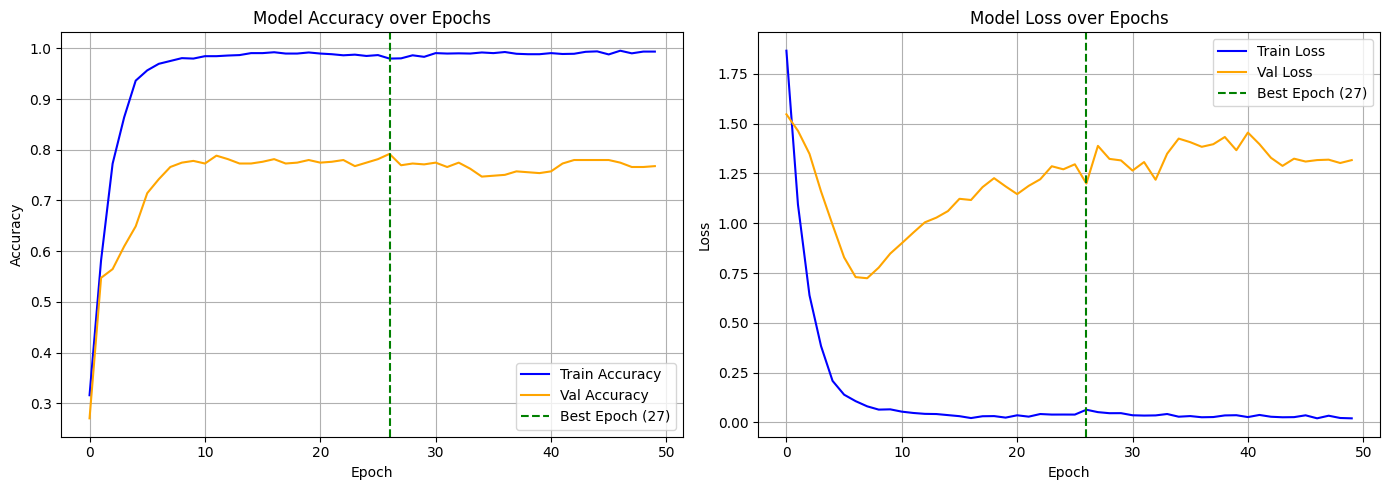

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history3.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history3.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.axvline(x=26, color='green', linestyle='--', label='Best Epoch (27)')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history3.history['loss'], label='Train Loss', color='blue')
ax2.plot(history3.history['val_loss'], label='Val Loss', color='orange')
ax2.axvline(x=26, color='green', linestyle='--', label='Best Epoch (27)')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Testing the Model with New Descriptions

This section demonstrates how the trained `model3` can predict genres for new, unseen movie descriptions. The process involves several key steps:

*   **Prepare New Descriptions**: A list of example movie descriptions (`test_descriptions`) is created to simulate real-world input.
*   **Vectorize Descriptions**: The `test_descriptions` are transformed into numerical feature vectors using the same `vectorizer2` (TF-IDF vectorizer) that was fitted on the training data. This ensures consistency in feature representation.
*   **Make Predictions**: The `model3.predict()` method is called with the vectorized test descriptions to obtain probability distributions over the five genres for each description.
*   **Decode Predictions**: The `predictions.argmax(axis=1)` function identifies the index of the highest probability for each prediction, corresponding to the most likely genre. These indices are then mapped back to their original genre names using `encoder2.classes_`.
*   **Display Results**: The original description, the predicted genre, and the model's confidence (the highest probability) are printed for each test case, providing a clear demonstration of the model's performance.

In [30]:
# Test on real examples!
test_descriptions = [
    "A group of friends go on a camping trip but are hunted by a terrifying monster",
    "A stand-up comedian performs his latest show about relationships and life",
    "Scientists explore the mysteries of the deep ocean and marine life",
    "A superhero battles evil forces to save the world from destruction",
    "Kids go on a magical adventure with talking animals in an enchanted forest"
]

# Vectorize using our trained vectorizer
test_vectors = vectorizer2.transform(test_descriptions).toarray()

# Predict
predictions = model3.predict(test_vectors)
predicted_genres = encoder2.classes_[predictions.argmax(axis=1)]

print("Genre Predictions:\n")

for desc, genre, probs in zip(test_descriptions, predicted_genres, predictions):
    print(f"Description: '{desc[:60]}...'")
    print(f"Predicted Genre: {genre}")
    print(f"Confidence: {probs.max()*100:.1f}%")
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Genre Predictions:

Description: 'A group of friends go on a camping trip but are hunted by a ...'
Predicted Genre: Horror Movies
Confidence: 100.0%

Description: 'A stand-up comedian performs his latest show about relations...'
Predicted Genre: Stand-Up Comedy
Confidence: 100.0%

Description: 'Scientists explore the mysteries of the deep ocean and marin...'
Predicted Genre: Documentaries
Confidence: 100.0%

Description: 'A superhero battles evil forces to save the world from destr...'
Predicted Genre: Action & Adventure
Confidence: 52.8%

Description: 'Kids go on a magical adventure with talking animals in an en...'
Predicted Genre: Children & Family Movies
Confidence: 100.0%



Put any word to find movies including that search

### Search for Movies by Title

This code cell allows you to search for movies within the `df_movies` dataset whose titles contain a specified keyword. The search is case-insensitive, and the results are printed as a list of matching movie titles. This is useful for quickly finding movies of interest before using them for recommendations.

In [28]:
# Search for a movie name in dataset
search = "war"
matches = df_movies[df_movies['title'].str.lower().str.contains(search)]
print(matches['title'].tolist())

['The Swarm', 'Dynasty Warriors', 'Rogue Warfare: Death of a Nation', 'Awara Paagal Deewana', 'Ghosts of War', "Best Wishes, Warmest Regards: A Schitt's Creek Farewell", 'Rogue Warfare: The Hunt', 'Rogue Warfare', 'Park Na-rae: Glamour Warning', 'War Against Women', 'Anthony Jeselnik: Fire in the Maternity Ward', 'Alien Warfare', 'Arjun: The Warrior Prince', 'Hari Kondabolu: Warn Your Relatives', 'Russell Howard: Recalibrate', 'Enter the Warriors Gate', 'Joe Mande’s Award-Winning Comedy Special', 'Apache Warrior', 'Attacking the Devil: Harold Evans and the Last Nazi War Crime', 'Avengers: Infinity War', 'Bruno and Boots: The Wizzle War', "Defying the Nazis: The Sharps' War", 'God of War', 'Harriet the Spy: Blog Wars', 'Iliza Shlesinger: War Paint', 'Solo: A Star Wars Story', 'Solo: A Star Wars Story (Spanish Version)', 'Star Wars: Episode VIII: The Last Jedi', 'The 24 Hour War', 'The Art of War', 'War', 'War on Everyone', 'Warda']


### Movie Recommendation Function

This section defines and demonstrates the `recommend_movies` function, which provides movie recommendations based on a given movie title. The process involves several steps:

1.  **Movie Lookup**: The function first searches for the input `movie_title` in the `df_movies` dataset (case-insensitive).
2.  **Description Vectorization**: If the movie is found, its description is vectorized using the `vectorizer2` (TF-IDF vectorizer) to convert it into a numerical representation.
3.  **Genre Prediction**: The `model3` (the refined Neural Network) is used to predict the genre of the input movie's description, along with a confidence score.
4.  **Genre Filtering**: The dataset is then filtered to find other movies belonging to the *same predicted genre* as the input movie.
5.  **Similarity Calculation**: The descriptions of these same-genre movies are vectorized, and `cosine_similarity` is used to calculate how similar each of them is to the input movie's description.
6.  **Top Recommendations**: The function identifies and displays the top `n` most similar movies, along with their similarity scores and descriptions, providing a personalized recommendation list.

at the very end use the title to get the recomended movies

In [31]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_movies(movie_title, top_n=5):
    movie = df_movies[df_movies['title'].str.lower() == movie_title.lower()]

    if movie.empty:
        print(f"Movie '{movie_title}' not found in dataset.")
        print("Suggested titles:", df_movies['title'].sample(5).tolist())
        return

    movie_desc = movie['description'].values[0]
    movie_vec = vectorizer2.transform([movie_desc]).toarray()

    pred_probs = model3.predict(movie_vec, verbose=0)
    predicted_genre = encoder2.classes_[pred_probs.argmax()]
    confidence = pred_probs.max() * 100

    print(f"Movie: {movie['title'].values[0]}")
    print(f"Detected Genre: {predicted_genre} ({confidence:.1f}% confidence)")
    print(f"Description: {movie_desc[:100]}...")
    print(f"\nTop {top_n} Similar Movies:\n")

    same_genre = df_movies[
        (df_movies['genre'] == predicted_genre) &
        (df_movies['title'] != movie['title'].values[0])
    ]

    same_genre_vecs = vectorizer2.transform(
        same_genre['description']
    ).toarray()

    similarities = cosine_similarity(movie_vec, same_genre_vecs)[0]

    top_indices = similarities.argsort()[::-1][:top_n]
    top_movies = same_genre.iloc[top_indices]
    top_scores = similarities[top_indices]

    for i, (_, row) in enumerate(top_movies.iterrows(), 1):
        print(f"{i}. {row['title']}")
        print(f"   Similarity: {top_scores[i-1]*100:.1f}%")
        print(f"   Description: {row['description'][:80]}...")
        print()

# Test it
recommend_movies("War Against Women")

Movie: War Against Women
Detected Genre: Documentaries (100.0% confidence)
Description: Filmed over three years in 10 countries, this documentary gives voice to the women who have become v...

Top 5 Similar Movies:

1. Martyrs of Marriage
   Similarity: 34.6%
   Description: This documentary reveals the cracks in India's anti-dowry act and gives voice to...

2. The Silence of Others
   Similarity: 25.5%
   Description: Filmed over six years, this documentary captures the struggles of victims who su...

3. Ayotzinapa, el paso de la tortuga
   Similarity: 15.4%
   Description: Delving into the disappearance of 43 college students in Mexico, this documentar...

4. Elles ont toutes une histoire
   Similarity: 10.4%
   Description: From Asia, Africa and Latin America, five women share extraordinary stories of s...

5. Miss Americana
   Similarity: 9.6%
   Description: In this revealing documentary, Taylor Swift embraces her role as a songwriter an...

